# Delivery Performance & Operations

Fast, reliable delivery is one of the few things e-commerce platforms 
can control that directly impacts customer satisfaction. This notebook 
looks at delivery times, late delivery rates, and, the important part - 
whether late deliveries actually hurt review scores.

The connection between ops performance and customer sentiment is the 
kind of analysis that bridges the gap between operations teams and 
business leadership.

In [47]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

con = duckdb.connect()

DATA_PATH = r"C:\Users\UCWAcc\projects\ecommerce-analytics\data"

con.execute(f"""
    CREATE TABLE customers AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_customers_dataset.csv');
    CREATE TABLE orders AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_orders_dataset.csv');
    CREATE TABLE order_items AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_items_dataset.csv');
    CREATE TABLE products AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_products_dataset.csv');
    CREATE TABLE sellers AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_sellers_dataset.csv');
    CREATE TABLE reviews AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_reviews_dataset.csv');
    CREATE TABLE geolocation AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_geolocation_dataset.csv');
    CREATE TABLE category_translation AS SELECT * FROM read_csv_auto('{DATA_PATH}/product_category_name_translation.csv');
""")

def sql(query):
    return con.execute(query).fetchdf()

## Overall delivery time stats

How long does it typically take from purchase to delivery? And how does 
that compare to what customers were promised?

In [49]:
delivery_stats = sql("""
    SELECT 
        COUNT(*) AS delivered_orders,
        ROUND(AVG(DATEDIFF('day', order_purchase_timestamp, order_delivered_customer_date)), 1) AS avg_delivery_days,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (
            ORDER BY DATEDIFF('day', order_purchase_timestamp, order_delivered_customer_date)
        ), 1) AS median_delivery_days,
        MIN(DATEDIFF('day', order_purchase_timestamp, order_delivered_customer_date)) AS fastest,
        MAX(DATEDIFF('day', order_purchase_timestamp, order_delivered_customer_date)) AS slowest
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
""")
delivery_stats

,delivered_orders,avg_delivery_days,median_delivery_days,fastest,slowest
0,96470,12.5,10.0,0,210


## How often are deliveries late?

"Late" = delivered after the estimated delivery date. This is the number 
customers actually care about — they don't know the internal logistics, 
they just know what the app promised them.

In [51]:
late_rate = sql("""
    SELECT 
        COUNT(*) AS total_delivered,
        SUM(CASE 
            WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 
            ELSE 0 
        END) AS late_deliveries,
        ROUND(SUM(CASE 
            WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 
            ELSE 0 
        END) * 100.0 / COUNT(*), 1) AS late_pct,
        ROUND(AVG(CASE 
            WHEN order_delivered_customer_date > order_estimated_delivery_date 
            THEN DATEDIFF('day', order_estimated_delivery_date, order_delivered_customer_date) 
        END), 1) AS avg_days_late_when_late
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
""")
late_rate

,total_delivered,late_deliveries,late_pct,avg_days_late_when_late
0,96470,7826.0,8.1,8.9


## Delivery time by customer state

Brazil is huge — someone in São Paulo is a lot closer to most warehouses 
than someone in Amazonas. Geographic disparities in delivery time can 
explain a lot of the variance in customer satisfaction.

In [53]:
by_state = sql("""
    SELECT c.customer_state,
           COUNT(*) AS orders,
           ROUND(AVG(DATEDIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date)), 1) AS avg_days,
           ROUND(SUM(CASE 
               WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 
               ELSE 0 
           END) * 100.0 / COUNT(*), 1) AS late_pct
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
    HAVING COUNT(*) >= 50
    ORDER BY avg_days DESC
""")
by_state

,customer_state,orders,avg_days,late_pct
0,AP,67,27.2,4.5
1,AM,145,26.4,4.1
2,AL,397,24.5,23.9
3,PA,946,23.7,12.4
4,SE,335,21.5,15.2
5,MA,717,21.5,19.7
6,CE,1279,21.2,15.3
7,AC,80,21.0,3.8
8,PB,517,20.4,11.0
9,PI,476,19.4,16.0


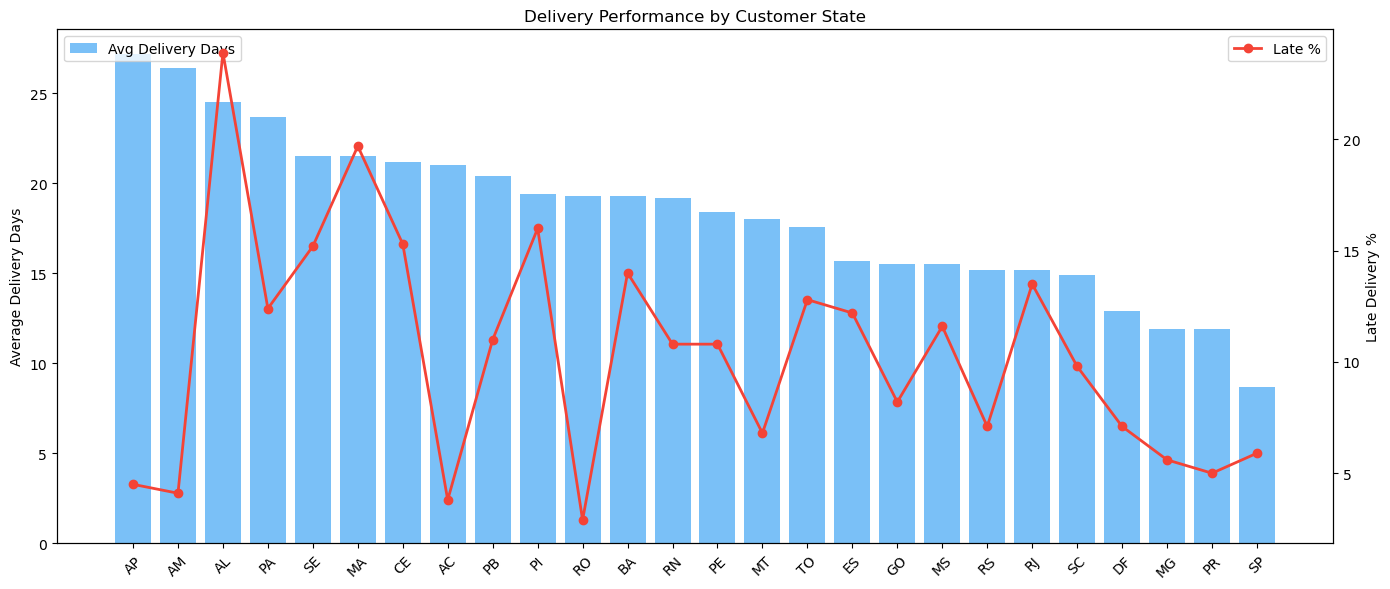

In [54]:
fig, ax1 = plt.subplots(figsize=(14, 6))

x = range(len(by_state))
ax1.bar(x, by_state['avg_days'], alpha=0.6, color='#2196F3', label='Avg Delivery Days')
ax1.set_ylabel('Average Delivery Days')

ax2 = ax1.twinx()
ax2.plot(x, by_state['late_pct'], color='#F44336', marker='o', linewidth=2, label='Late %')
ax2.set_ylabel('Late Delivery %')

ax1.set_xticks(x)
ax1.set_xticklabels(by_state['customer_state'], rotation=45)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Delivery Performance by Customer State')
plt.tight_layout()
plt.show()

## The big question: do late deliveries hurt reviews?

This is where the analysis gets interesting. Everyone assumes late 
delivery = bad review, but let's quantify it. How big is the gap 
in review scores between on-time and late orders?

In [56]:
late_vs_reviews = sql("""
    SELECT 
        CASE 
            WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 'Late'
            ELSE 'On Time'
        END AS delivery_status,
        COUNT(*) AS orders,
        ROUND(AVG(r.review_score), 2) AS avg_review,
        SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END) AS low_reviews,
        ROUND(SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS low_review_pct,
        SUM(CASE WHEN r.review_score >= 4 THEN 1 ELSE 0 END) AS high_reviews,
        ROUND(SUM(CASE WHEN r.review_score >= 4 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS high_review_pct
    FROM orders o
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
    GROUP BY delivery_status
""")
late_vs_reviews

,delivery_status,orders,avg_review,low_reviews,low_review_pct,high_reviews,high_review_pct
0,Late,7700,2.57,4160.0,54.0,2665.0,34.6
1,On Time,88653,4.29,8186.0,9.2,73381.0,82.8


## How bad does "late" have to be before reviews tank?

Not all late deliveries are equal. Being 1 day late is different from 
being 2 weeks late. Let's bucket the delay and see where the review 
damage really kicks in.

In [58]:
delay_buckets = sql("""
    WITH delivery_data AS (
        SELECT o.order_id,
               r.review_score,
               DATEDIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS days_diff
        FROM orders o
        JOIN reviews r ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
          AND o.order_estimated_delivery_date IS NOT NULL
    )
    SELECT CASE
               WHEN days_diff <= -7 THEN '7+ days early'
               WHEN days_diff BETWEEN -6 AND -1 THEN '1-6 days early'
               WHEN days_diff = 0 THEN 'On time'
               WHEN days_diff BETWEEN 1 AND 3 THEN '1-3 days late'
               WHEN days_diff BETWEEN 4 AND 7 THEN '4-7 days late'
               WHEN days_diff BETWEEN 8 AND 14 THEN '1-2 weeks late'
               ELSE '2+ weeks late'
           END AS delivery_bucket,
           MIN(days_diff) AS bucket_sort,
           COUNT(*) AS orders,
           ROUND(AVG(review_score), 2) AS avg_review
    FROM delivery_data
    GROUP BY delivery_bucket
    ORDER BY bucket_sort
""")
delay_buckets

,delivery_bucket,bucket_sort,orders,avg_review
0,7+ days early,-147,76175,4.31
1,1-6 days early,-6,12478,4.18
2,On time,0,1291,4.03
3,1-3 days late,1,1856,3.29
4,4-7 days late,4,1756,2.10
5,1-2 weeks late,8,1452,1.68
6,2+ weeks late,15,1345,1.72


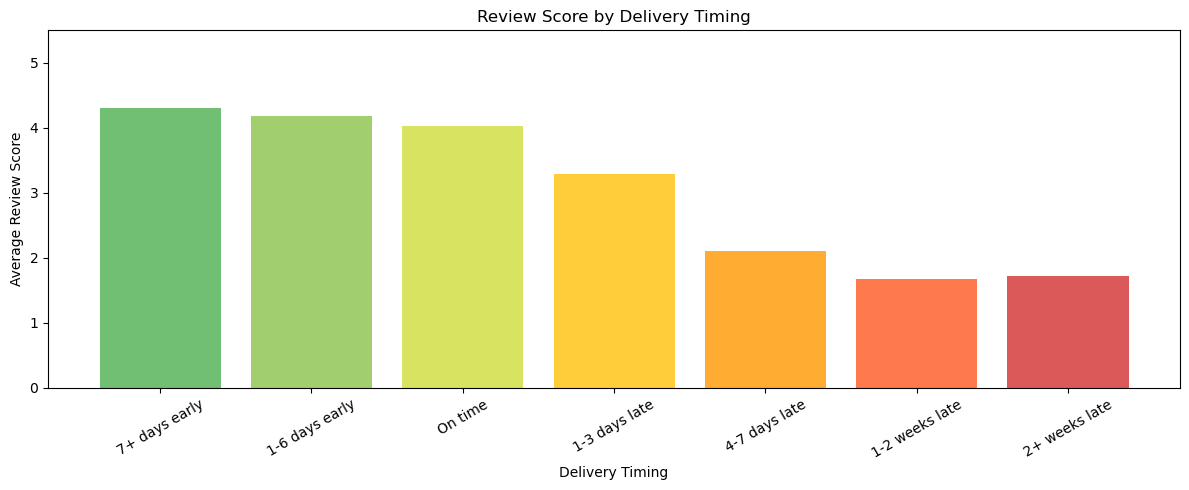

In [59]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4CAF50', '#8BC34A', '#CDDC39', '#FFC107', '#FF9800', '#FF5722', '#D32F2F']
colors = colors[:len(delay_buckets)]
ax.bar(delay_buckets['delivery_bucket'], delay_buckets['avg_review'], color=colors, alpha=0.8)
ax.set_ylabel('Average Review Score')
ax.set_xlabel('Delivery Timing')
ax.set_title('Review Score by Delivery Timing')
ax.set_ylim(0, 5.5)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Monthly trend in delivery performance

Is delivery getting better or worse over time? Operations teams care 
about this trajectory more than the snapshot.

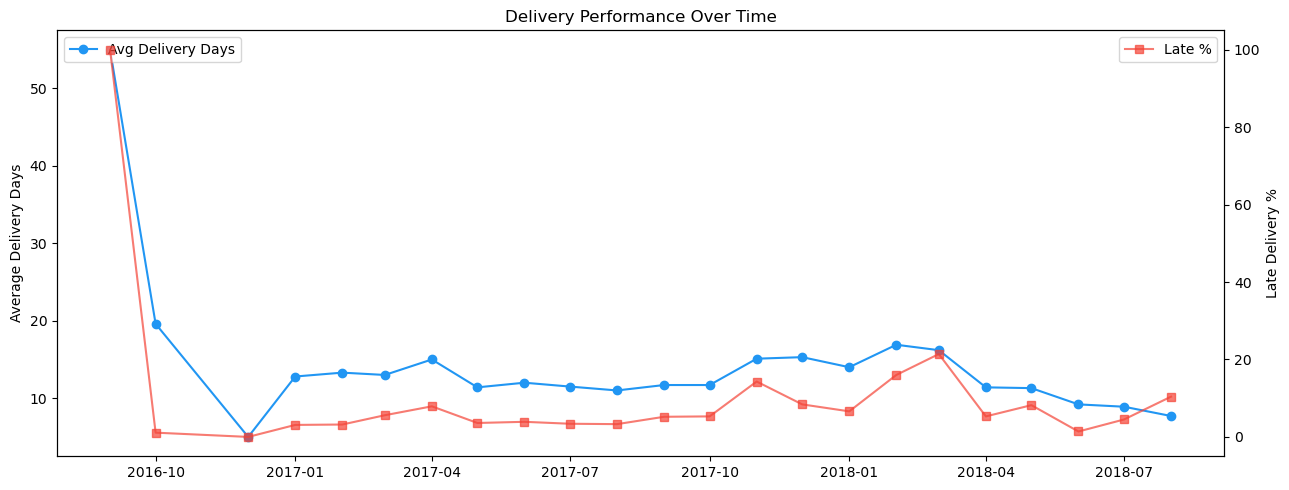

In [61]:
monthly_delivery = sql("""
    SELECT DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
           COUNT(*) AS orders,
           ROUND(AVG(DATEDIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date)), 1) AS avg_days,
           ROUND(SUM(CASE 
               WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 
               ELSE 0 
           END) * 100.0 / COUNT(*), 1) AS late_pct
    FROM orders o
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY month
    ORDER BY month
""")

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(monthly_delivery['month'], monthly_delivery['avg_days'], color='#2196F3', marker='o', label='Avg Delivery Days')
ax1.set_ylabel('Average Delivery Days')

ax2 = ax1.twinx()
ax2.plot(monthly_delivery['month'], monthly_delivery['late_pct'], color='#F44336', marker='s', label='Late %', alpha=0.7)
ax2.set_ylabel('Late Delivery %')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Delivery Performance Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Does distance drive delivery time?

The geolocation dataset gives us lat/long coordinates for each zip code. 
We can estimate the straight-line distance between seller and customer 
and check whether it actually predicts how long delivery takes. This is 
the geographic version of the state-level analysis above — but with 
actual distances instead of just state labels.

In [63]:
# Get one representative lat/lng per zip code (average of all entries)
# Then calculate approximate distance between seller and customer

distance_vs_delivery = sql("""
    WITH seller_geo AS (
        SELECT geolocation_zip_code_prefix AS zip,
               AVG(geolocation_lat) AS lat,
               AVG(geolocation_lng) AS lng
        FROM geolocation
        GROUP BY geolocation_zip_code_prefix
    ),
    customer_geo AS (
        SELECT geolocation_zip_code_prefix AS zip,
               AVG(geolocation_lat) AS lat,
               AVG(geolocation_lng) AS lng
        FROM geolocation
        GROUP BY geolocation_zip_code_prefix
    ),
    order_distances AS (
        SELECT o.order_id,
               DATEDIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date) AS delivery_days,
               -- Haversine approximation: ~111km per degree at Brazil's latitude
               ROUND(SQRT(
                   POWER((sg.lat - cg.lat) * 111, 2) +
                   POWER((sg.lng - cg.lng) * 85, 2)
               ), 0) AS distance_km
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        JOIN sellers s ON oi.seller_id = s.seller_id
        JOIN customers c ON o.customer_id = c.customer_id
        JOIN seller_geo sg ON s.seller_zip_code_prefix = sg.zip
        JOIN customer_geo cg ON c.customer_zip_code_prefix = cg.zip
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    SELECT CASE
               WHEN distance_km < 100 THEN '0-100 km'
               WHEN distance_km < 300 THEN '100-300 km'
               WHEN distance_km < 500 THEN '300-500 km'
               WHEN distance_km < 1000 THEN '500-1000 km'
               WHEN distance_km < 2000 THEN '1000-2000 km'
               ELSE '2000+ km'
           END AS distance_bucket,
           MIN(distance_km) AS bucket_sort,
           COUNT(*) AS orders,
           ROUND(AVG(delivery_days), 1) AS avg_delivery_days,
           ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delivery_days), 1) AS median_delivery_days
    FROM order_distances
    WHERE distance_km IS NOT NULL AND delivery_days > 0
    GROUP BY distance_bucket
    ORDER BY bucket_sort
""")
distance_vs_delivery

,distance_bucket,bucket_sort,orders,avg_delivery_days,median_delivery_days
0,0-100 km,0.0,21235,6.5,5.0
1,100-300 km,100.0,21134,10.8,9.0
2,300-500 km,300.0,26515,12.3,10.0
3,500-1000 km,500.0,24883,14.5,12.0
4,1000-2000 km,1000.0,10952,18.2,16.0
5,2000+ km,2000.0,4933,21.5,19.0


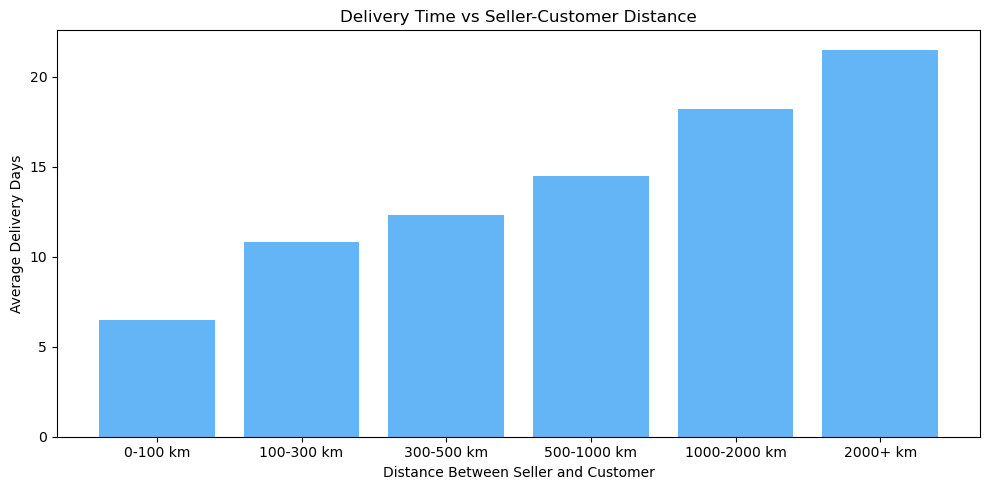

In [64]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(distance_vs_delivery['distance_bucket'], distance_vs_delivery['avg_delivery_days'],
       color='#2196F3', alpha=0.7)
ax.set_ylabel('Average Delivery Days')
ax.set_xlabel('Distance Between Seller and Customer')
ax.set_title('Delivery Time vs Seller-Customer Distance')
plt.tight_layout()
plt.show()

The pattern is clear — longer distances mean longer delivery times. Orders 
within 100 km are significantly faster than cross-country shipments. This 
confirms that the seller concentration in São Paulo (from notebook 04) 
has direct consequences for customers in distant states.

In [66]:
# Top 10 customer cities by order volume

top_cities = sql("""
    SELECT g.geolocation_city AS city,
           g.geolocation_state AS state,
           COUNT(DISTINCT o.order_id) AS orders,
           ROUND(AVG(DATEDIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date)), 1) AS avg_delivery_days
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN (
        SELECT geolocation_zip_code_prefix, 
               FIRST(geolocation_city) AS geolocation_city,
               FIRST(geolocation_state) AS geolocation_state
        FROM geolocation
        GROUP BY geolocation_zip_code_prefix
    ) g ON c.customer_zip_code_prefix = g.geolocation_zip_code_prefix
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY g.geolocation_city, g.geolocation_state
    HAVING COUNT(DISTINCT o.order_id) >= 100
    ORDER BY orders DESC
    LIMIT 15
""")
top_cities

,city,state,orders,avg_delivery_days
0,sao paulo,SP,12819,8.0
1,rio de janeiro,RJ,6592,14.7
2,belo horizonte,MG,2697,11.0
3,são paulo,SP,2224,8.2
4,curitiba,PR,1489,10.4
5,brasilia,DF,1449,13.0
6,campinas,SP,1406,9.8
7,porto alegre,RS,1341,15.9
8,salvador,BA,1185,19.3
9,guarulhos,SP,1143,8.0


## Takeaways

**Late deliveries destroy customer satisfaction.** On-time orders average 4.29 stars. Late orders average 2.57 - a 1.7-point gap on a 5-point scale. This isn't subtle: lateness is the single strongest driver of bad reviews in this dataset.

**The damage is proportional and severe.** The dose-response pattern is striking: 1-3 days late drops reviews to 3.29, 4-7 days late to 2.10, and 1-2 weeks late craters to 1.68. Customers don't just dislike lateness — they punish it progressively. The ops priority should be preventing multi-week delays (which destroy brand perception) over marginal improvements to average delivery time.

**8.1% late rate is manageable but not negligible.** About 7,800 out of 96,000 delivered orders arrived after the estimated date. That's roughly 1 in 12 orders - enough to generate a steady stream of negative reviews and customer complaints.

**Geographic disparities drive much of the problem.** Delivery times and late rates vary significantly by customer state. Customers far from the seller clusters (which are concentrated in São Paulo) face structurally longer delivery windows. The cheapest intervention may be adjusting estimated delivery dates for remote states - under-promise and over-deliver - rather than overhauling the physical logistics network. A delivery that arrives in 15 days against a 20-day estimate feels early; the same 15 days against a 10-day estimate feels late. Perception is the lever here.
